# StayGuard: Machine Learning Modeling

## 1. Modeling Overview

This notebook focuses on building supervised classification models to predict hotel booking cancellations.

The objective is to compare different machine learning models and evaluate their ability to identify bookings at risk of cancellation.

Since the target variable is moderately imbalanced, model performance will be evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)

## 2. Load Cleaned Dataset

The cleaned dataset created in the previous notebook is loaded from the `data/processed/` folder.

In [2]:
df = pd.read_csv("../data/processed/hotel_reservations_clean.csv")

df.head()

,booking_id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 3. Feature and Target Definition

Before training the models, the dataset is divided into:

- `X`: predictive features used by the model.
- `y`: target variable indicating whether the booking was cancelled.

The `booking_id` column is removed because it is only an identifier and does not contain useful predictive information.

In [3]:
# Define features and target

X = df.drop(columns=["booking_id", "booking_status"])
y = df["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

y.value_counts(normalize=True).mul(100).round(2)

Features shape: (36275, 17)
Target shape: (36275,)


booking_status
0    67.24
1    32.76
Name: proportion, dtype: float64

The target variable was encoded as:

- `0`: Not_Canceled
- `1`: Canceled

This encoding allows the machine learning models to treat the problem as a binary classification task.

## 4. Train-Test Split

The dataset is split into training and testing sets before preprocessing or model training.

A stratified split is used to preserve the original proportion of cancelled and non-cancelled bookings in both sets.

In [4]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (29020, 17)
X_test shape: (7255, 17)
y_train shape: (29020,)
y_test shape: (7255,)


In [5]:
# Check target distribution after split

split_distribution = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_percentage": y_test.value_counts(normalize=True).mul(100).round(2)
})

split_distribution

,train_percentage,test_percentage
booking_status,,
0,67.24,67.24
1,32.76,32.76


## 5. Preprocessing Pipeline

Machine learning models require numerical input. Therefore, categorical variables need to be encoded and numerical variables need to be scaled.

This is especially important for KNN, since it is a distance-based model and can be strongly affected by variables measured on different scales.

The preprocessing strategy is:

- One-hot encode categorical features.
- Standardize numerical features.
- Keep all transformations inside a pipeline to avoid data leakage.

In [6]:
# Identify categorical and numerical features

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

Numerical features:
['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']


In [7]:
# Define preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 6. Baseline Model: K-Nearest Neighbors

The first model tested is a K-Nearest Neighbors classifier.

KNN predicts the class of a booking based on the most similar observations in the training data. Since KNN is distance-based, scaling numerical variables is especially important.

This first version uses the default value of `n_neighbors=5`.

In [8]:
# Build KNN baseline pipeline

knn_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_baseline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
# Train KNN baseline model

knn_baseline.fit(X_train, y_train);

In [10]:
# Generate predictions

y_pred_knn = knn_baseline.predict(X_test)

In [11]:
# Evaluate KNN baseline model

knn_results = {
    "model": "KNN Baseline",
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "precision": precision_score(y_test, y_pred_knn),
    "recall": recall_score(y_test, y_pred_knn),
    "f1_score": f1_score(y_test, y_pred_knn)
}

knn_results_df = pd.DataFrame([knn_results]).round(4)

knn_results_df

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743


In [12]:
# Classification report

print(classification_report(y_test, y_pred_knn, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.88      0.91      0.89      4878
    Canceled       0.80      0.75      0.77      2377

    accuracy                           0.86      7255
   macro avg       0.84      0.83      0.83      7255
weighted avg       0.85      0.86      0.86      7255



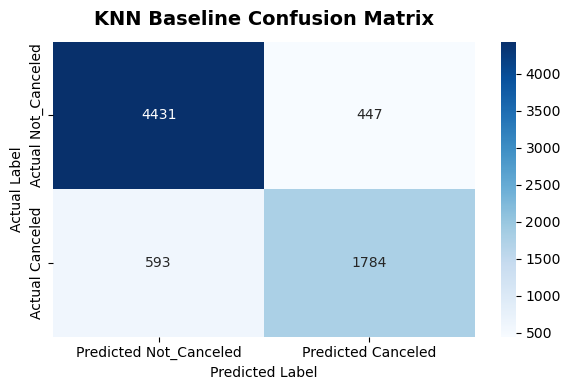

In [13]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("KNN Baseline Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### KNN Baseline Results

The KNN baseline model performs well as a first machine learning approach.

It achieves an accuracy of 85.67%, clearly outperforming the majority-class baseline of approximately 67%. More importantly, it identifies cancelled bookings with a recall of 75.05% and a precision of 79.96%.

From a business perspective, recall for the `Canceled` class is especially important because missed cancellations represent bookings that the hotel would incorrectly treat as safe.

The model correctly identifies 1,784 cancelled bookings, but misses 593 cancellations. This leaves room for improvement through hyperparameter tuning and comparison with other classification models.

In [14]:
# Store model results for later comparison

model_results = []

model_results.append(knn_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743


## 7. KNN Hyperparameter Tuning

The baseline KNN model used a fixed value of `n_neighbors=5`.

To improve performance, GridSearchCV is used to test different combinations of KNN hyperparameters, including the number of neighbors, distance weighting, and distance metric.

Cross-validation is applied on the training set to compare these combinations more reliably, while the test set remains untouched for final evaluation.

The optimization metric used is F1-score, since the project needs a balance between correctly identifying cancellations and avoiding too many false alarms.

In [15]:
# Define KNN hyperparameter grid

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [16]:
# Tune KNN model with GridSearchCV

knn_grid_search = GridSearchCV(
    estimator=knn_baseline,
    param_grid=knn_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(X_train, y_train);

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [17]:
# Best KNN parameters and cross-validation score

print("Best parameters:")
print(knn_grid_search.best_params_)

print(f"\nBest cross-validation F1-score: {knn_grid_search.best_score_:.4f}")

Best parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}

Best cross-validation F1-score: 0.7988


In [18]:
# Generate predictions with tuned KNN

y_pred_knn_tuned = knn_grid_search.predict(X_test)

In [19]:
# Evaluate tuned KNN model

knn_tuned_results = {
    "model": "KNN Tuned",
    "accuracy": accuracy_score(y_test, y_pred_knn_tuned),
    "precision": precision_score(y_test, y_pred_knn_tuned),
    "recall": recall_score(y_test, y_pred_knn_tuned),
    "f1_score": f1_score(y_test, y_pred_knn_tuned)
}

knn_tuned_results_df = pd.DataFrame([knn_tuned_results]).round(4)

knn_tuned_results_df

,model,accuracy,precision,recall,f1_score
0,KNN Tuned,0.8816,0.8401,0.7888,0.8136


In [20]:
# Classification report for tuned KNN

print(classification_report(y_test, y_pred_knn_tuned, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.90      0.93      0.91      4878
    Canceled       0.84      0.79      0.81      2377

    accuracy                           0.88      7255
   macro avg       0.87      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



### Tuned KNN Results

GridSearchCV selected the following KNN configuration:

- Distance metric: `manhattan`
- Number of neighbors: `15`
- Weights: `distance`

The tuned KNN model improves over the baseline model across all main metrics.

Accuracy increased from 85.67% to 88.16%, while the F1-score for the `Canceled` class increased from 77.43% to 81.36%.

This improvement suggests that hyperparameter tuning helped the model better balance precision and recall when identifying bookings at risk of cancellation.

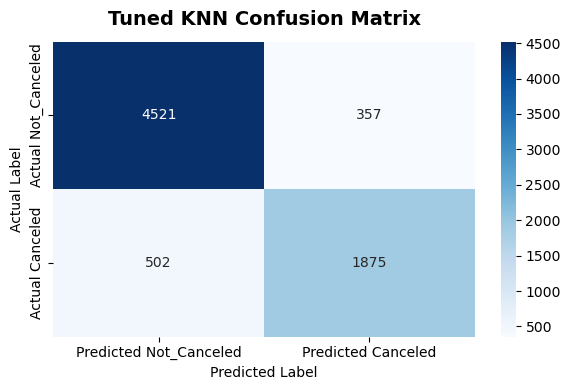

In [21]:
# Confusion matrix for tuned KNN

cm_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("Tuned KNN Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [22]:
# Store tuned KNN results

model_results.append(knn_tuned_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136


## 8. Logistic Regression Baseline

Logistic Regression is used as a second baseline model for binary classification.

Unlike KNN, Logistic Regression estimates the probability of a booking being cancelled based on the relationship between the input features and the target variable.

This model is useful because it is faster, more interpretable, and often provides a strong benchmark for classification problems.

In [23]:
# Build Logistic Regression baseline pipeline

logreg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_baseline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Train Logistic Regression baseline model

logreg_baseline.fit(X_train, y_train);

In [25]:
# Generate predictions

y_pred_logreg = logreg_baseline.predict(X_test)

In [26]:
# Evaluate Logistic Regression baseline model

logreg_results = {
    "model": "Logistic Regression Baseline",
    "accuracy": accuracy_score(y_test, y_pred_logreg),
    "precision": precision_score(y_test, y_pred_logreg),
    "recall": recall_score(y_test, y_pred_logreg),
    "f1_score": f1_score(y_test, y_pred_logreg)
}

logreg_results_df = pd.DataFrame([logreg_results]).round(4)

logreg_results_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943


In [27]:
# Classification report for Logistic Regression

print(classification_report(y_test, y_pred_logreg, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.84      0.90      0.87      4878
    Canceled       0.75      0.64      0.69      2377

    accuracy                           0.81      7255
   macro avg       0.80      0.77      0.78      7255
weighted avg       0.81      0.81      0.81      7255



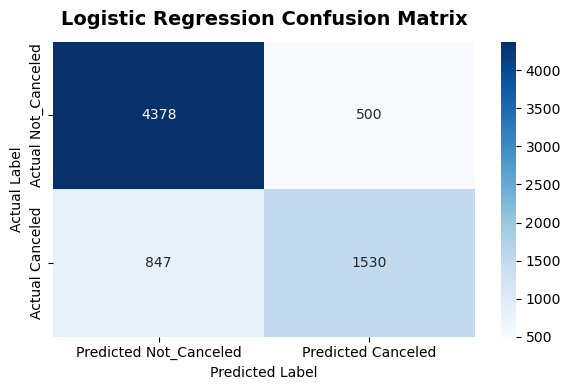

In [28]:
# Confusion matrix for Logistic Regression

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Logistic Regression Results

The Logistic Regression baseline performs reasonably well, but it underperforms compared to the tuned KNN model.

Its accuracy reaches 81.43%, but the recall for the `Canceled` class is only 64.37%. This means the model misses a relatively high number of actual cancellations.

Although Logistic Regression is more interpretable and computationally efficient, its predictive performance is weaker for this problem. In particular, it is less effective at identifying bookings at risk of cancellation.

For this reason, more flexible models will be tested next.

In [29]:
# Store Logistic Regression results

model_results.append(logreg_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136
2,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943


## 9. Decision Tree Baseline

A Decision Tree model is tested to capture non-linear relationships between booking features and cancellation behavior.

Unlike Logistic Regression, Decision Trees can split the data based on feature thresholds, which may be useful for variables such as `lead_time`, `avg_price_per_room`, and `no_of_special_requests`.

The same preprocessing pipeline is used to keep the workflow consistent across models.

In [32]:
# Build Decision Tree baseline pipeline

tree_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_baseline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
# Train Decision Tree baseline model

tree_baseline.fit(X_train, y_train);

In [34]:
# Generate predictions

y_pred_tree = tree_baseline.predict(X_test)

In [35]:
# Evaluate Decision Tree baseline model

tree_results = {
    "model": "Decision Tree Baseline",
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(y_test, y_pred_tree),
    "recall": recall_score(y_test, y_pred_tree),
    "f1_score": f1_score(y_test, y_pred_tree)
}

tree_results_df = pd.DataFrame([tree_results]).round(4)

tree_results_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree Baseline,0.8744,0.8109,0.8044,0.8076


In [36]:
# Classification report for Decision Tree

print(classification_report(y_test, y_pred_tree, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.91      0.91      0.91      4878
    Canceled       0.81      0.80      0.81      2377

    accuracy                           0.87      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.87      0.87      0.87      7255



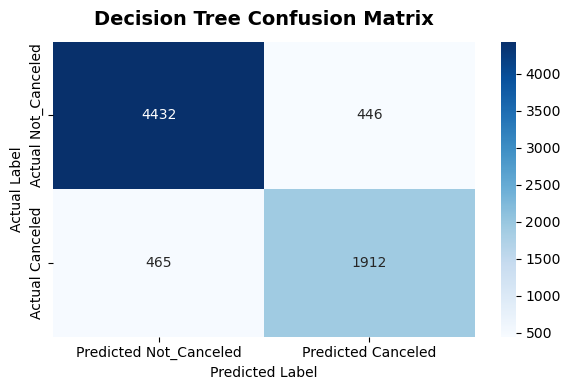

In [37]:
# Confusion matrix for Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("Decision Tree Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [38]:
# Store Decision Tree results

model_results.append(tree_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136
2,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943
3,Decision Tree Baseline,0.8744,0.8109,0.8044,0.8076


### Decision Tree Results

The Decision Tree baseline performs strongly and reaches an accuracy of 87.44%.

Compared to Logistic Regression, it captures cancellation behavior much better, especially for the `Canceled` class. Its recall for cancellations reaches 80.44%, meaning it identifies a large proportion of actual cancelled bookings.

Compared to the tuned KNN model, the Decision Tree has slightly lower overall F1-score but slightly higher recall for cancellations. This makes it interesting from a business perspective, since detecting risky bookings is one of the main goals of the project.

However, because the tree was trained without depth restrictions, it may be overfitting. The next step is to compare train and test performance.

In [39]:
# Check Decision Tree performance on train and test sets

y_train_pred_tree = tree_baseline.predict(X_train)

tree_train_results = {
    "dataset": "Train",
    "accuracy": accuracy_score(y_train, y_train_pred_tree),
    "precision": precision_score(y_train, y_train_pred_tree),
    "recall": recall_score(y_train, y_train_pred_tree),
    "f1_score": f1_score(y_train, y_train_pred_tree)
}

tree_test_results = {
    "dataset": "Test",
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(y_test, y_pred_tree),
    "recall": recall_score(y_test, y_pred_tree),
    "f1_score": f1_score(y_test, y_pred_tree)
}

tree_overfitting_check = pd.DataFrame([tree_train_results, tree_test_results]).round(4)

tree_overfitting_check

,dataset,accuracy,precision,recall,f1_score
0,Train,0.9941,0.9958,0.9863,0.9910
1,Test,0.8744,0.8109,0.8044,0.8076


### Decision Tree Overfitting Check

The Decision Tree shows a strong gap between training and test performance.

The model reaches an almost perfect F1-score on the training set, but performs notably lower on the test set. This indicates overfitting: the tree is learning patterns that are too specific to the training data instead of generalizing well to unseen bookings.

To reduce overfitting, the next step is to tune the tree using GridSearchCV with restrictions on tree depth, minimum samples per split, and minimum samples per leaf.

## 10. Decision Tree Hyperparameter Tuning

The baseline Decision Tree showed strong performance but also clear signs of overfitting.

GridSearchCV is used to search for a better tree configuration by limiting tree complexity. The goal is to improve generalization while maintaining strong performance on cancellation detection.

In [41]:
# Define Decision Tree hyperparameter grid

tree_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_split": [2, 10, 25, 50],
    "model__min_samples_leaf": [1, 5, 10, 20]
}

In [42]:
# Tune Decision Tree with GridSearchCV

tree_grid_search = GridSearchCV(
    estimator=tree_baseline,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

tree_grid_search.fit(X_train, y_train);

Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [43]:
# Best Decision Tree parameters and cross-validation score

print("Best parameters:")
print(tree_grid_search.best_params_)

print(f"\nBest cross-validation F1-score: {tree_grid_search.best_score_:.4f}")

Best parameters:
{'model__criterion': 'gini', 'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best cross-validation F1-score: 0.8037


In [44]:
# Generate predictions with tuned Decision Tree

y_pred_tree_tuned = tree_grid_search.predict(X_test)

In [45]:
# Evaluate tuned Decision Tree model

tree_tuned_results = {
    "model": "Decision Tree Tuned",
    "accuracy": accuracy_score(y_test, y_pred_tree_tuned),
    "precision": precision_score(y_test, y_pred_tree_tuned),
    "recall": recall_score(y_test, y_pred_tree_tuned),
    "f1_score": f1_score(y_test, y_pred_tree_tuned)
}

tree_tuned_results_df = pd.DataFrame([tree_tuned_results]).round(4)

tree_tuned_results_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree Tuned,0.8841,0.8328,0.8086,0.8205


In [46]:
# Classification report for tuned Decision Tree

print(classification_report(y_test, y_pred_tree_tuned, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.91      0.92      0.91      4878
    Canceled       0.83      0.81      0.82      2377

    accuracy                           0.88      7255
   macro avg       0.87      0.86      0.87      7255
weighted avg       0.88      0.88      0.88      7255



### Tuned Decision Tree Results

The tuned Decision Tree improves over the baseline tree and becomes the strongest model so far.

It achieves an accuracy of 88.41% and an F1-score of 82.05% for the `Canceled` class. Compared to the untuned tree, the tuned version improves precision, recall, and overall F1-score.

This suggests that controlling tree complexity helped the model generalize better while still capturing important non-linear cancellation patterns.

At this stage, the tuned Decision Tree is the best-performing model.

In [47]:
# Best Decision Tree parameters

tree_grid_search.best_params_

{'model__criterion': 'gini',
 'model__max_depth': 12,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2}

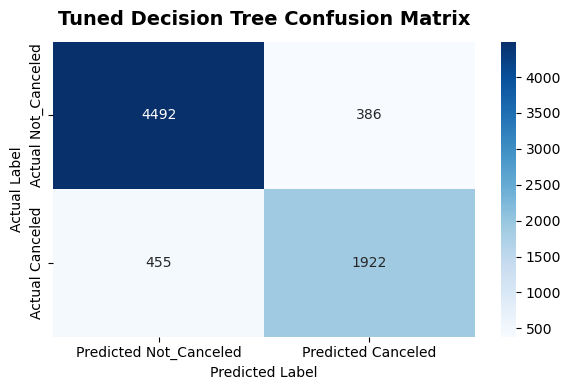

In [48]:
# Confusion matrix for tuned Decision Tree

cm_tree_tuned = confusion_matrix(y_test, y_pred_tree_tuned)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm_tree_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("Tuned Decision Tree Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [49]:
# Store tuned Decision Tree results

model_results.append(tree_tuned_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136
2,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943
3,Decision Tree Baseline,0.8744,0.8109,0.8044,0.8076
4,Decision Tree Tuned,0.8841,0.8328,0.8086,0.8205


## 11. Random Forest Baseline

Random Forest is an ensemble model that combines multiple decision trees to improve predictive performance and reduce overfitting.

Instead of relying on a single tree, the model builds many trees using different samples and feature combinations, then combines their predictions.

This makes Random Forest a strong candidate for this project, especially after observing that a single Decision Tree performed well but showed signs of overfitting.

In [51]:
# Build Random Forest baseline pipeline

rf_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_baseline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
# Train Random Forest baseline model

rf_baseline.fit(X_train, y_train);

In [53]:
# Generate predictions

y_pred_rf = rf_baseline.predict(X_test)

In [54]:
# Evaluate Random Forest baseline model

rf_results = {
    "model": "Random Forest Baseline",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1_score": f1_score(y_test, y_pred_rf)
}

rf_results_df = pd.DataFrame([rf_results]).round(4)

rf_results_df

,model,accuracy,precision,recall,f1_score
0,Random Forest Baseline,0.9068,0.8882,0.8187,0.852


In [55]:
# Classification report for Random Forest

print(classification_report(y_test, y_pred_rf, target_names=["Not_Canceled", "Canceled"]))

              precision    recall  f1-score   support

Not_Canceled       0.91      0.95      0.93      4878
    Canceled       0.89      0.82      0.85      2377

    accuracy                           0.91      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.91      0.91      0.91      7255



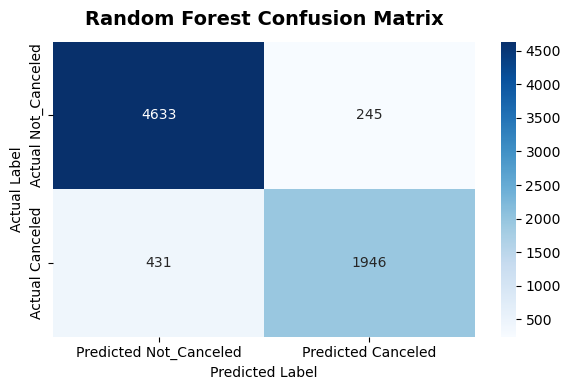

In [56]:
# Confusion matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not_Canceled", "Predicted Canceled"],
    yticklabels=["Actual Not_Canceled", "Actual Canceled"]
)

plt.title("Random Forest Confusion Matrix", fontsize=14, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [57]:
# Store Random Forest results

model_results.append(rf_results)

pd.DataFrame(model_results).round(4)

,model,accuracy,precision,recall,f1_score
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136
2,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943
3,Decision Tree Baseline,0.8744,0.8109,0.8044,0.8076
4,Decision Tree Tuned,0.8841,0.8328,0.8086,0.8205
5,Random Forest Baseline,0.9068,0.8882,0.8187,0.8520


### Random Forest Baseline Results

The Random Forest baseline is the strongest model so far.

It achieves an accuracy of 90.68% and an F1-score of 85.20% for the `Canceled` class, outperforming both the tuned KNN and the tuned Decision Tree.

The model also improves precision substantially, meaning that when it predicts a booking as cancelled, it is correct more often than previous models.

This result suggests that combining multiple decision trees helps capture complex cancellation patterns while improving generalization compared to a single tree.

In [58]:
# Check Random Forest performance on train and test sets

y_train_pred_rf = rf_baseline.predict(X_train)

rf_train_results = {
    "dataset": "Train",
    "accuracy": accuracy_score(y_train, y_train_pred_rf),
    "precision": precision_score(y_train, y_train_pred_rf),
    "recall": recall_score(y_train, y_train_pred_rf),
    "f1_score": f1_score(y_train, y_train_pred_rf)
}

rf_test_results = {
    "dataset": "Test",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1_score": f1_score(y_test, y_pred_rf)
}

rf_overfitting_check = pd.DataFrame([rf_train_results, rf_test_results]).round(4)

rf_overfitting_check

,dataset,accuracy,precision,recall,f1_score
0,Train,0.9941,0.9944,0.9877,0.991
1,Test,0.9068,0.8882,0.8187,0.852


### Random Forest Overfitting Check

The Random Forest model achieves almost perfect performance on the training set, while test performance is lower.

This indicates some overfitting, but the model still generalizes better than the previous models tested. Compared to a single Decision Tree, Random Forest achieves stronger test performance by combining multiple trees and reducing reliance on one specific tree structure.

To check whether generalization can be improved further, the next step is to tune the Random Forest hyperparameters.

## 12. Random Forest Hyperparameter Tuning

The Random Forest baseline achieved the strongest performance so far, but the train-test comparison suggests some overfitting.

GridSearchCV is used to test different Random Forest configurations and search for a better balance between model complexity and generalization.

The tuning process focuses on tree depth, minimum samples required for splits and leaves, and the number of trees in the forest.

In [59]:
# Define Random Forest hyperparameter grid

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt"]
}

In [60]:
# Tune Random Forest with GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=rf_baseline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train);

Fitting 3 folds for each of 54 candidates, totalling 162 fits


In [61]:
# Best Random Forest parameters and cross-validation score

print("Best parameters:")
print(rf_grid_search.best_params_)

print(f"\nBest cross-validation F1-score: {rf_grid_search.best_score_:.4f}")

Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best cross-validation F1-score: 0.8328


### Random Forest Tuning Results

GridSearchCV selected the same configuration used by the Random Forest baseline model:

- `n_estimators`: 300
- `max_depth`: None
- `min_samples_split`: 2
- `min_samples_leaf`: 1
- `max_features`: sqrt

Because the tuned configuration matches the baseline setup, the tuned model does not provide a new improvement over the existing Random Forest result.

For this reason, the Random Forest baseline is kept as the final Random Forest model and the duplicate tuned result is not added to the final model comparison.

## 13. Model Comparison

All trained models are compared using the same test set.

The main evaluation metric is F1-score for the `Canceled` class, since the objective is to balance cancellation detection with prediction reliability.

Accuracy is also considered, but it is not used as the only decision metric because the target variable is moderately imbalanced.

In [65]:
# Compare all model results

model_comparison = pd.DataFrame(model_results).round(4)
model_comparison = model_comparison.sort_values("f1_score", ascending=False)

model_comparison

,model,accuracy,precision,recall,f1_score
5,Random Forest Baseline,0.9068,0.8882,0.8187,0.8520
4,Decision Tree Tuned,0.8841,0.8328,0.8086,0.8205
1,KNN Tuned,0.8816,0.8401,0.7888,0.8136
3,Decision Tree Baseline,0.8744,0.8109,0.8044,0.8076
0,KNN Baseline,0.8567,0.7996,0.7505,0.7743
2,Logistic Regression Baseline,0.8143,0.7537,0.6437,0.6943


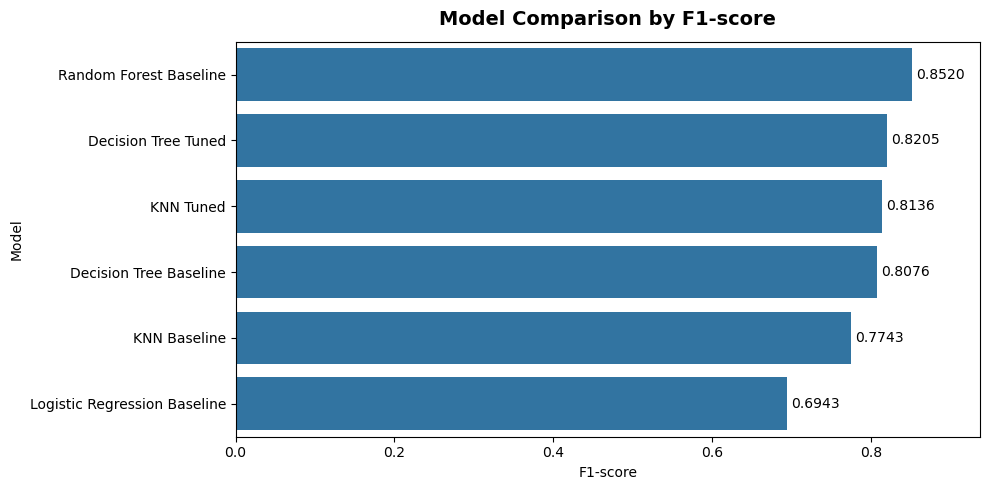

In [66]:
# Visualize model comparison by F1-score

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=model_comparison, x="f1_score", y="model")

for container in ax.containers:
    ax.bar_label(container, labels=[f"{v.get_width():.4f}" for v in container], padding=3)

plt.title("Model Comparison by F1-score", fontsize=14, weight="bold", pad=12)
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.xlim(0, model_comparison["f1_score"].max() * 1.1)
plt.tight_layout()
plt.show()

### Model Comparison Insights

Random Forest achieved the best overall performance among the tested models.

It reached the highest F1-score for the `Canceled` class, meaning it provided the best balance between correctly identifying actual cancellations and avoiding excessive false cancellation predictions.

The tuned Decision Tree also performed strongly, but Random Forest delivered better precision, recall, accuracy, and F1-score.

Logistic Regression was the weakest model for this problem, suggesting that the relationship between booking features and cancellations is not purely linear.

Based on the final comparison, Random Forest is selected as the best model for this project.

## 14. Feature Importance

After selecting Random Forest as the best-performing model, feature importance is analyzed to understand which variables contributed most to the predictions.

This helps connect model performance with business interpretation.

In [67]:
# Extract feature names after preprocessing

feature_names = rf_baseline.named_steps["preprocessor"].get_feature_names_out()

# Extract feature importances from Random Forest model

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_baseline.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
5,num__lead_time,0.314264
12,num__avg_price_per_room,0.156614
13,num__no_of_special_requests,0.101796
8,num__arrival_date,0.095765
7,num__arrival_month,0.084066
3,num__no_of_week_nights,0.053234
2,num__no_of_weekend_nights,0.037749
29,cat__market_segment_type_Online,0.027097
6,num__arrival_year,0.025496
0,num__no_of_adults,0.023560


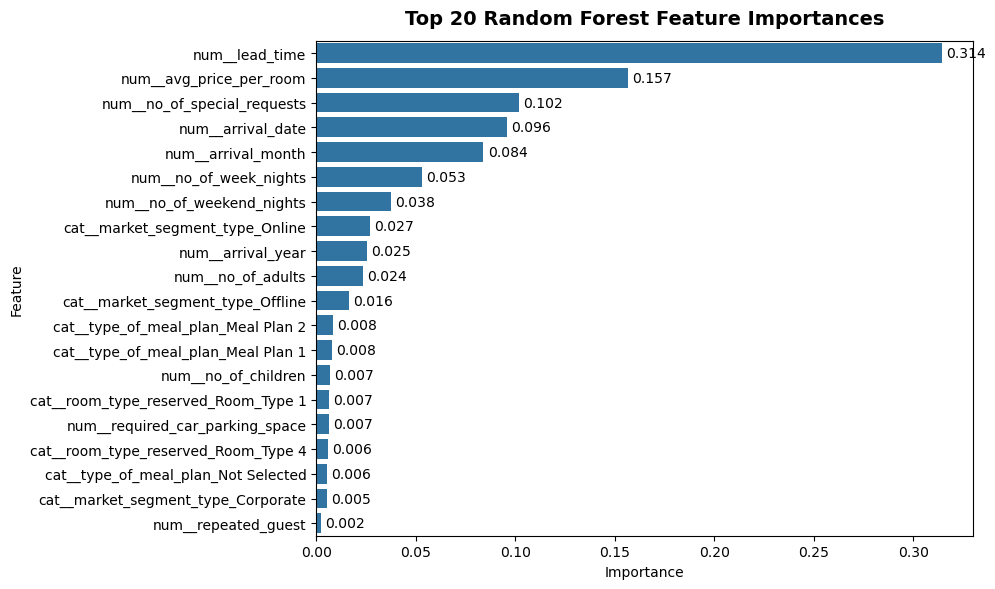

In [68]:
# Visualize top 20 feature importances

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top_features, x="importance", y="feature")

for container in ax.containers:
    ax.bar_label(container, labels=[f"{v.get_width():.3f}" for v in container], padding=3)

plt.title("Top 20 Random Forest Feature Importances", fontsize=14, weight="bold", pad=12)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Correlation Analysis

A correlation analysis is performed to understand the linear relationships between numerical features and the target variable.

This step does not replace model-based feature importance, since Random Forest can capture non-linear patterns. However, it helps identify variables that are directly associated with cancellations and detect potential redundancy between numerical predictors.

In [69]:
# Create encoded target for correlation analysis

df_corr = df.copy()
df_corr["booking_status_encoded"] = df_corr["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

numeric_corr_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr_matrix = df_corr[numeric_corr_cols].corr()

target_correlations = (
    corr_matrix["booking_status_encoded"]
    .drop("booking_status_encoded")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

target_correlations.columns = ["feature", "correlation_with_cancellation"]

target_correlations

,feature,correlation_with_cancellation
0,lead_time,0.438538
1,no_of_special_requests,-0.253070
2,arrival_year,0.179529
3,avg_price_per_room,0.142569
4,repeated_guest,-0.107287
5,no_of_week_nights,0.092996
6,no_of_adults,0.086920
7,required_car_parking_space,-0.086185
8,no_of_weekend_nights,0.061563
9,no_of_previous_bookings_not_canceled,-0.060179


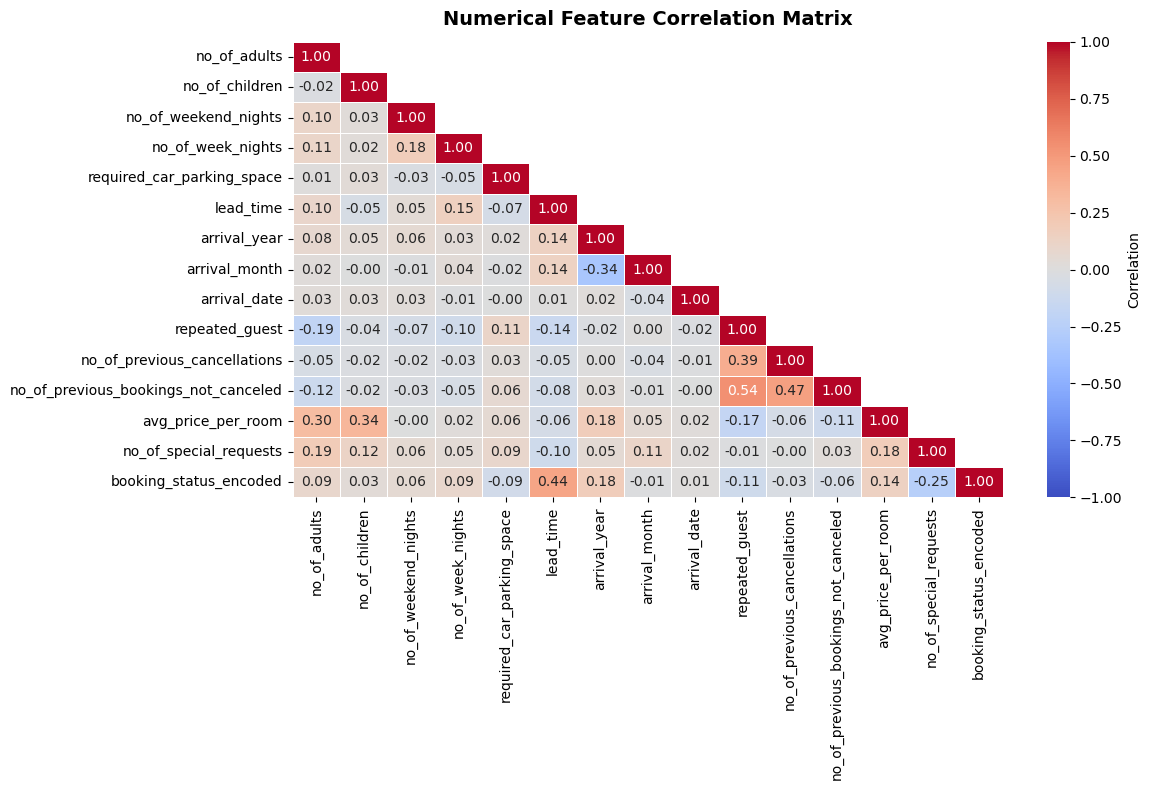

In [74]:
# Correlation heatmap for numerical features (lower triangle with annotations)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Numerical Feature Correlation Matrix", fontsize=14, weight="bold", pad=12)
plt.tight_layout()
plt.show()

### Correlation Insights

The strongest numerical correlation with cancellations is `lead_time`, with a positive correlation of 0.44. This supports the earlier EDA finding that bookings made further in advance are more likely to be cancelled.

`no_of_special_requests` shows the strongest negative correlation with cancellations, suggesting that bookings with more special requests are less likely to be cancelled.

`avg_price_per_room` and `arrival_year` also show positive correlations, although weaker than `lead_time`.

Overall, the correlation analysis confirms that some numerical features are linearly related to cancellation behavior, but the relationships are not strong enough to rely on correlation alone. This supports the use of non-linear models such as Random Forest.

In [75]:
# Identify highly correlated numerical feature pairs

corr_pairs = (
    corr_matrix
    .drop(columns=["booking_status_encoded"], errors="ignore")
    .drop(index=["booking_status_encoded"], errors="ignore")
    .abs()
    .unstack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
high_corr_pairs = corr_pairs[corr_pairs["correlation"] >= 0.70].sort_values("correlation", ascending=False)

high_corr_pairs

,feature_1,feature_2,correlation


### Redundancy Check

No numerical feature pairs showed a correlation above 0.70.

This suggests that there is no strong redundancy between the numerical predictors, so no variables are removed based on correlation.

All selected features will be kept for the final model.

### Feature Importance and Correlation Summary

Both feature importance and correlation analysis point to `lead_time` as the strongest predictor of booking cancellations.

`no_of_special_requests` is also highly relevant, showing both strong model importance and a negative relationship with cancellations.

Other features such as `avg_price_per_room`, arrival timing variables, length of stay, and market segment also contribute to the model.

Since Random Forest can capture non-linear relationships and interactions between variables, the final feature selection is based primarily on model performance and feature importance rather than correlation alone.

## 16. Save Final Model

The Random Forest model is selected as the final model because it achieved the best performance on the test set.

The full pipeline, including preprocessing and the trained model, is saved so it can be reused later without manually repeating the transformation steps.

In [77]:
# Save final model pipeline

joblib.dump(rf_baseline, "../models/random_forest_final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


## 17. Final Conclusion

The objective of this project was to build a machine learning model capable of predicting hotel booking cancellations using reservation-level information.

Several classification models were tested, including KNN, Logistic Regression, Decision Tree, and Random Forest. Since the target variable was moderately imbalanced, model selection was based mainly on the F1-score for the `Canceled` class rather than accuracy alone.

Random Forest achieved the best overall performance, with strong accuracy, precision, recall, and F1-score. It outperformed the other models by better balancing cancellation detection with prediction reliability.

The most important predictive features were `lead_time`, `avg_price_per_room`, `no_of_special_requests`, arrival timing variables, and market segment. These findings are consistent with the exploratory analysis, where longer lead times and fewer special requests were strongly associated with higher cancellation risk.

From a business perspective, this model could help hotels identify high-risk bookings in advance, improve revenue management, adjust communication strategies, and reduce uncertainty around occupancy planning.

Future improvements could include testing additional models, optimizing probability thresholds, adding external data such as seasonality or events, and validating the model on more recent hotel booking data.